In [ ]:
import os 
import pandas as pd
import xarray as xr
import numpy as np
import pprint
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
from cartopy.util import add_cyclic_point
import sys 
import argparse
import logging
from tqdm import tqdm
# set python path   
os.chdir('/home/disk/brume/nacc/gradient_dissent/DLESyM')
sys.path.append('/home/disk/brume/nacc/gradient_dissent/DLESyM')
import data_processing.remap.healpix as hpx 
logging.basicConfig(level=logging.INFO)
logger = logging.getLogger(__name__)

In [ ]:
# adds grey as the lowest color. good for sparse fields.
def get_custom_cmap(cmap_base='Blues', white_levels=20, start_color=0):

    # Create a colormap that goes from grey to white
    cmap1 = mcolors.LinearSegmentedColormap.from_list("mycmap", ['whitesmoke', 'whitesmoke'])

    # Get the 'YlOrRd' colormap
    cmap2 = plt.get_cmap(cmap_base)

    # Combine the two colormaps
    colors = np.vstack((cmap1(np.linspace(0, 1, white_levels)), cmap2(np.linspace(start_color, 1, 128))))
    cmap_combined = mcolors.LinearSegmentedColormap.from_list('colormap', colors)
    return cmap_combined

def plot_average_precip_seasonal(
    forecast_file: str,
    output_dir: str,
):
    # open dataset 
    ds = xr.open_dataset(forecast_file).pr

    # calculate seasonal average
    ds_seasonal = ds.groupby('time.season').mean(dim='time')

    # remap seasonal averages 
    mapper = hpx.HEALPixRemap(
        latitudes=181,
        longitudes=360,
        nside=64,
    )
    remap_buffer = np.zeros((len(ds_seasonal.season), 181, 360), dtype=np.float32)
    for i, s in tqdm(
        enumerate(ds_seasonal.season),
        desc="Season",
        unit="season",
        total=len(ds_seasonal.season),
    ):
        remap_buffer[i] = mapper.hpx2ll(ds_seasonal.sel(season=s).values)
    # put together dataarray object
    ds_seasonal_ll = xr.DataArray(
        remap_buffer,
        dims=['season', 'lat', 'lon'],
        coords={
            'season': ds_seasonal.season,
            'lat': np.arange(90, -90.1, -1),
            'lon': np.arange(0, 360, 1),
        },
    )
    # initaliza figure 
    fig, axs = plt.subplots(
        nrows = 2, ncols = 2,
        figsize=(15, 10),
        subplot_kw={'projection': ccrs.PlateCarree()},
    )

    # plot seasonal average
    for i, ax in enumerate(axs.flatten()):
        
        ax.coastlines()

        # add cyclic point 
        data, lons = add_cyclic_point(ds_seasonal_ll.sel(season=ds_seasonal_ll.season[i]).values, coord=ds_seasonal_ll.lon)

        im = ax.contourf(
            lons,
            ds_seasonal_ll.lat,
            data,
            levels=10,
            cmap=get_custom_cmap('Blues'),
        )

        ax.set_title(ds_seasonal_ll.season[i].values)

    # formatting and colorbar
    fig.subplots_adjust(bottom=.1)
    cbax = fig.add_axes([.1,.1,.8, .02])
    fig.colorbar(im,cax=cbax,label='Precipitation (mm/day)', orientation='horizontal')


def validate_precip_forecast(file, output_dir, show=True):

    # create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # plot average precip seasonal 
    plot_average_precip_seasonal(
        forecast_file=file,
        output_dir=output_dir,
    )

Season: 100%|██████████| 4/4 [00:01<00:00,  2.45season/s]


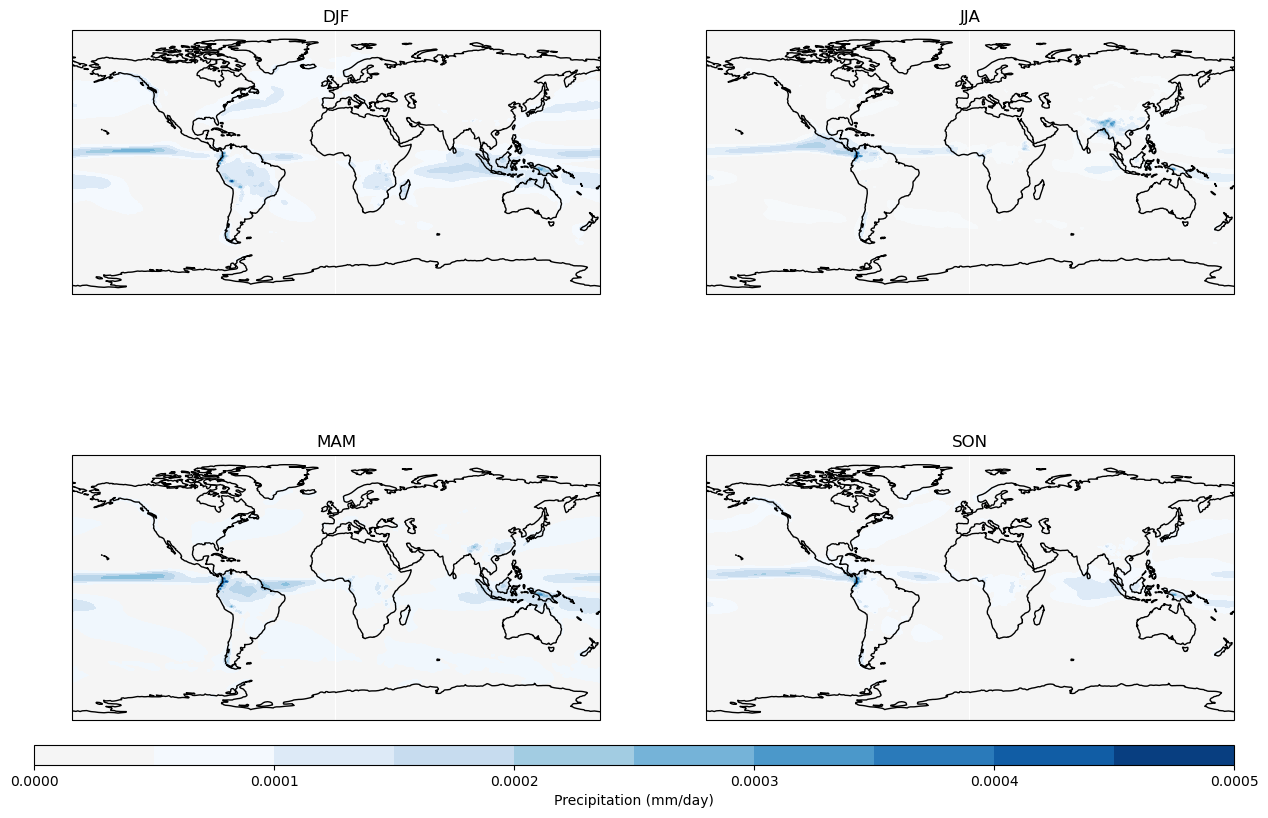

In [15]:
experiment = 'aimip'
r = 1

validate_precip_forecast(
    file=f'/home/disk/mercury3/nacc/aimip_subission_1978/university_of_washington/DLESyM/{experiment}/r{r}i1p1f1/Amon/pr/gn/v20260406/pr_Amon_DLESyM_{experiment}_r{r}i1p1f1_gn_19781016-20241216.nc',
    output_dir=f'/home/disk/mercury2/nacc/AIMIP2026/DLESyM/aimip/notebooks/precip_check/{experiment}_r{r}',
    show=True,
)


In [3]:
aimip_r1

<xarray.Dataset>
Dimensions:  (face: 12, height: 64, width: 64, time: 555)
Coordinates:
  * face     (face) int32 0 1 2 3 4 5 6 7 8 9 10 11
  * height   (height) int32 0 1 2 3 4 5 6 7 8 9 ... 55 56 57 58 59 60 61 62 63
  * width    (width) int32 0 1 2 3 4 5 6 7 8 9 ... 54 55 56 57 58 59 60 61 62 63
  * time     (time) datetime64[ns] 1978-10-16 1978-11-16 ... 2024-12-16
Data variables:
    pr       (time, face, height, width) float32 ...
Attributes:
    Conventions:     CF-1.8
    source_id:       DLESyM
    institution_id:  University of Washington
    time_units:      days since 1850-01-01 00:00:00
    time_calendar:   gregorian

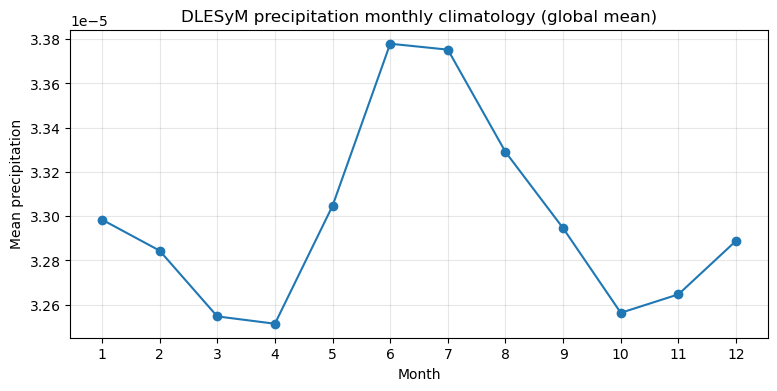

In [4]:
# Monthly climatology (average over all years)
pr = aimip_r1['pr']

monthly_mean_global = pr.groupby('time.month').mean(dim=['time', 'face', 'height', 'width'])

plt.figure(figsize=(9, 4))
plt.plot(monthly_mean_global['month'], monthly_mean_global, marker='o')
plt.xticks(np.arange(1, 13))
plt.xlabel('Month')
plt.ylabel('Mean precipitation')
plt.title('DLESyM precipitation monthly climatology (global mean)')
plt.grid(alpha=0.3)
plt.show()

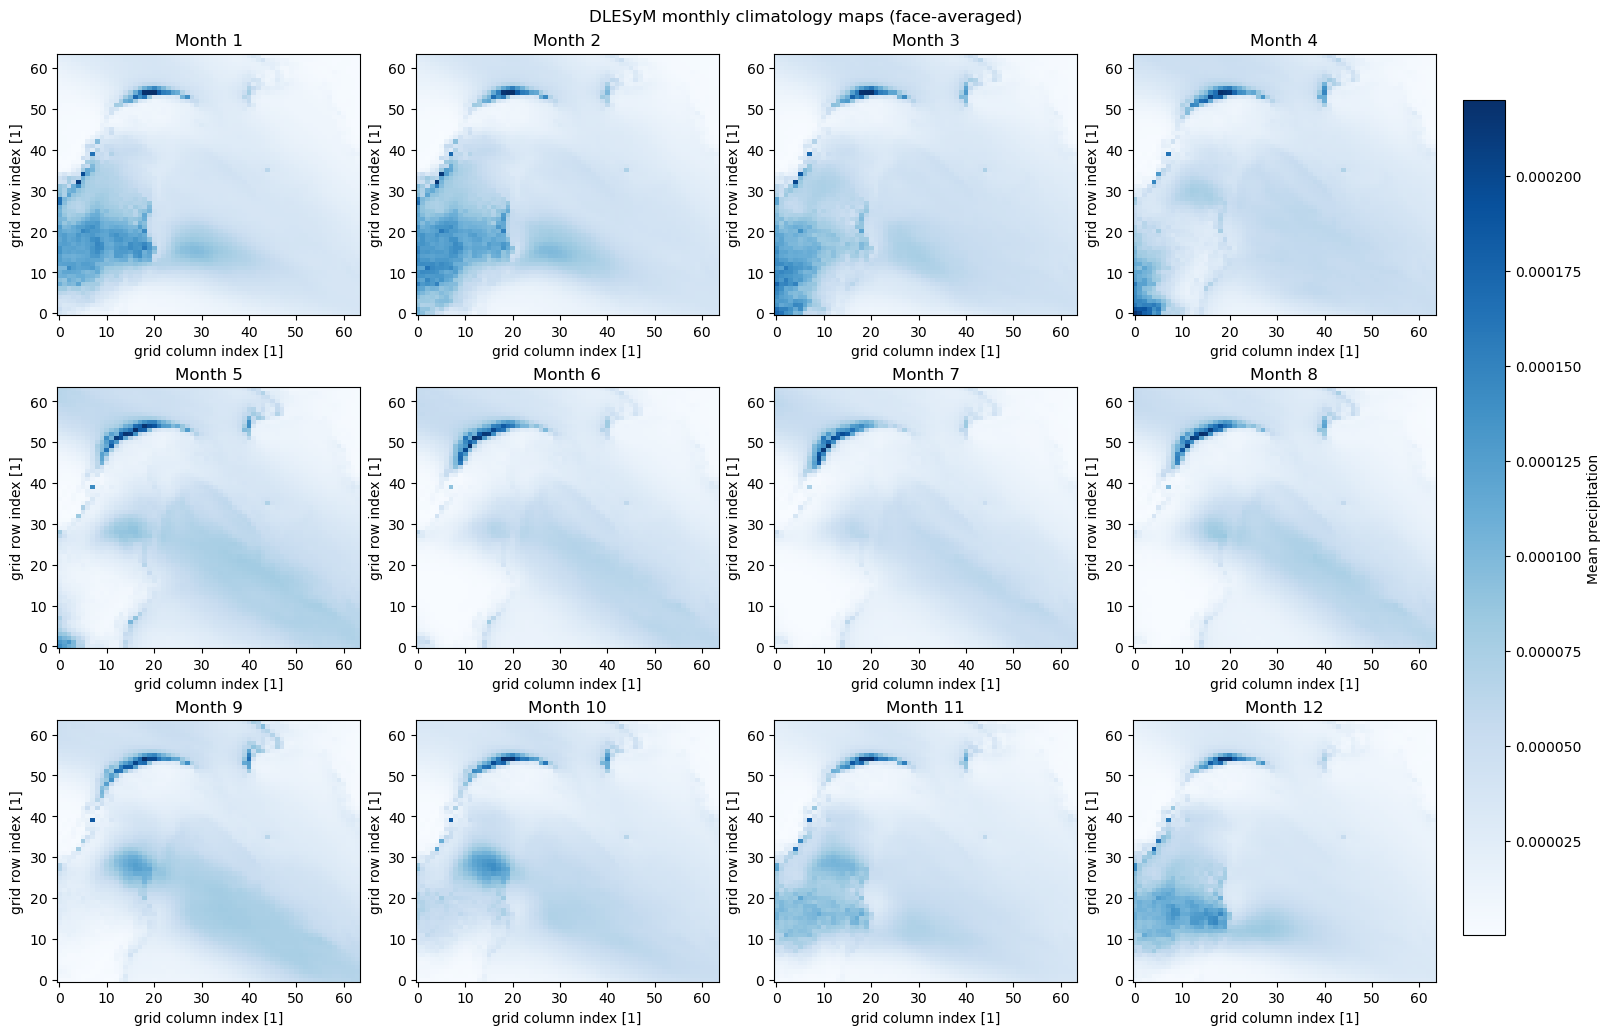

In [8]:
# Monthly mean maps (one panel per month)
monthly_mean_maps = pr.groupby('time.month').mean(dim='time')

fig, axes = plt.subplots(3, 4, figsize=(16, 10), constrained_layout=True)
axes = axes.ravel()

for month in range(1, 13):
    ax = axes[month - 1]
    panel = monthly_mean_maps.sel(month=month, face=11)
    im = panel.plot(ax=ax, cmap='Blues', add_colorbar=False)
    ax.set_title(f'Month {month}')

cbar = fig.colorbar(im, ax=axes.tolist(), shrink=0.9, pad=0.02)
cbar.set_label('Mean precipitation')
plt.suptitle('DLESyM monthly climatology maps (face-averaged)', y=1.02)
plt.show()